In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from skimage.feature import hog

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset loaded successfully!")
print("Image data shape:", X.shape)
print("Labels shape:", y.shape)

Loading MNIST dataset...
Dataset loaded successfully!
Image data shape: (70000, 784)
Labels shape: (70000,)


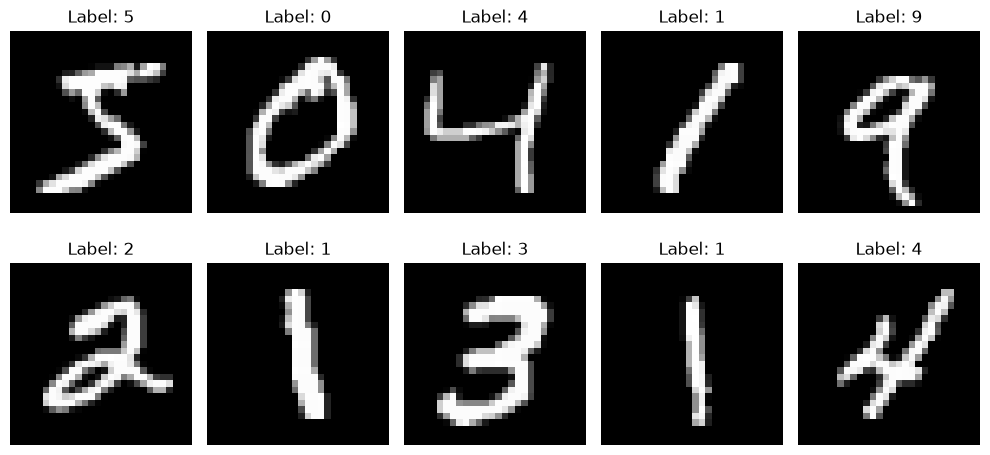

In [3]:
# Display sample digits

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image = X[i].reshape(28, 28)

    ax.imshow(image, cmap='gray')

    ax.set_title(f"Label: {y[i]}")

    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_train.shape)
print("Testing images :", X_test.shape)

Training images: (56000, 784)
Testing images : (14000, 784)


In [5]:
# Use only 5000 training images

train_size = 5000

X_train_small = X_train[:train_size]
y_train_small = y_train[:train_size]

print("Training samples:", X_train_small.shape)

Training samples: (5000, 784)


In [6]:
# Reshape images to 28x28

X_train_images = X_train_small.reshape(-1, 28, 28)
X_test_images = X_test.reshape(-1, 28, 28)

print("Training image shape:", X_train_images.shape)
print("Testing image shape :", X_test_images.shape)

Training image shape: (5000, 28, 28)
Testing image shape : (14000, 28, 28)


In [7]:
# Extract HOG features from training images

hog_train = []

for image in X_train_images:

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    hog_train.append(features)

hog_train = np.array(hog_train)

print("Training HOG feature shape:", hog_train.shape)

Training HOG feature shape: (5000, 1296)


In [8]:
# Extract HOG features from testing images

hog_test = []

for image in X_test_images:

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    hog_test.append(features)

hog_test = np.array(hog_test)

print("Testing HOG feature shape:", hog_test.shape)

Testing HOG feature shape: (14000, 1296)


In [9]:
# Train the SVM classifier

print("Training SVM...")

svm = SVC(
    kernel='rbf',
    gamma='scale'
)

svm.fit(hog_train, y_train_small)

print("Training completed!")

Training SVM...
Training completed!


In [10]:
# Predict on the testing data

print("Predicting...")

predictions = svm.predict(hog_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy * 100:.2f}%")

Predicting...
Accuracy: 97.45%


In [11]:
import joblib

In [12]:
import os

print(os.getcwd())

C:\Users\M S I\OneDrive\Desktop\digit recognizer\digit-recognizer\notebooks


In [13]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'svm_hog_training.ipynb']


In [14]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nModels Folder Exists?")
print(os.path.exists("../models"))

print("\nContents of Parent Folder:")
print(os.listdir(".."))

Current Working Directory:
C:\Users\M S I\OneDrive\Desktop\digit recognizer\digit-recognizer\notebooks

Models Folder Exists?
True

Contents of Parent Folder:
['.ipynb_checkpoints', 'app', 'data', 'digit_recognizer_app.ipynb', 'models', 'notebooks', 'outputs', 'README.md', 'requirements.txt', 'scripts']


In [15]:
import os
import joblib

# Create the folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(svm, "../models/svm_hog_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
